## Exploratory Data Analysis

In [1]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
import warnings
from typing import List, Tuple, Union, Any

# Set style for plots
sns.set_style("whitegrid")
warnings.filterwarnings('ignore') 

# Define custom params for plots
rcParams = {
    'font.size': 20,                # all fonts-size in plot
    'font.weight': 'bold',          # bold all fonts
    'figure.titleweight': 'bold',   # bold supertitle
    'axes.linewidth' : 6,
    'xtick.major.width': 6,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'lines.linewidth': 6,
    'legend.fontsize': 'large',
    'xtick.labelsize': 'large',
    'ytick.labelsize': 'large',
    'xtick.labelsize': 20,   # sets x-tick font size
    'ytick.labelsize': 20,
    'axes.titlepad': 20,   # spacing between suptitle and figure
    'axes.facecolor': 'white'
}

# Update rcparams
mpl.rcParams.update(rcParams) 

### Data understanding and Preparation

In [3]:
# read data
raw_df = pd.read_csv('./raw_data/bank_data.csv', sep = ';')
print(f"Shape of data: {raw_df.shape}")

Shape of data: (41188, 21)


In [4]:
print(f"The number of columns in the data: {raw_df.shape[1]}")
print(f"Column names: {raw_df.columns.values}")

The number of columns in the data: 21
Column names: <StringArray>
[           'age',            'job',        'marital',      'education',
        'default',        'housing',           'loan',        'contact',
          'month',    'day_of_week',       'duration',       'campaign',
          'pdays',       'previous',       'poutcome',   'emp.var.rate',
 'cons.price.idx',  'cons.conf.idx',      'euribor3m',    'nr.employed',
              'y']
Length: 21, dtype: str


##### Bank Client Data Description
1. **age**: Age of the client (numeric).
2. **job**: Type of job (categorical):
   - "admin."
   - "blue-collar"
   - "entrepreneur"
   - "housemaid"
   - "management"
   - "retired"
   - "self-employed"
   - "services"
   - "student"
   - "technician"
   - "unemployed"
   - "unknown"
3. **marital**: Marital status (categorical):
   - "divorced" (includes divorced and widowed)
   - "married"
   - "single"
   - "unknown"
4. **education**: Level of education (categorical):
   - "basic.4y"
   - "basic.6y"
   - "basic.9y"
   - "high.school"
   - "illiterate"
   - "professional.course"
   - "university.degree"
   - "unknown"
5. **default**: Has credit in default? (categorical):
   - "no"
   - "yes"
   - "unknown"
6. **housing**: Has housing loan? (categorical):
   - "no"
   - "yes"
   - "unknown"
7. **loan**: Has personal loan? (categorical):
   - "no"
   - "yes"
   - "unknown"

##### Last Contact of the Current Campaign
8. **contact**: Contact communication type (categorical):
   - "cellular"
   - "telephone"
9. **month**: Last contact month of the year (categorical):
   - "jan", "feb", "mar", ..., "nov", "dec"
10. **day_of_week**: Last contact day of the week (categorical):
    - "mon", "tue", "wed", "thu", "fri"
11. **duration**: Last contact duration in seconds (numeric). 

Note: This attribute highly affects the output target. If `duration=0`, then `y="no"`. This input should only be included for benchmark purposes and should be discarded for realistic predictive models.

##### Other Attributes
12. **campaign**: Number of contacts performed during this campaign and for this client (numeric, includes last contact).
13. **pdays**: Number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted).
14. **previous**: Number of contacts performed before this campaign and for this client (numeric).
15. **poutcome**: Outcome of the previous marketing campaign (categorical):
    - "failure"
    - "nonexistent"
    - "success"

##### Social and Economic Context Attributes
16. **emp.var.rate**: Employment variation rate - quarterly indicator (numeric).
17. **cons.price.idx**: Consumer price index - monthly indicator (numeric).
18. **cons.conf.idx**: Consumer confidence index - monthly indicator (numeric).
19. **euribor3m**: Euribor 3 month rate - daily indicator (numeric).
20. **nr.employed**: Number of employees - quarterly indicator (numeric).

##### Output Variable (Desired Target)
21. **y**: Has the client subscribed to a term deposit? (binary: "yes", "no").


##### Acknowledgments
- The dataset is provided by [A data-driven approach to predict the success of bank telemarketing](http://archive.ics.uci.edu/ml/datasets/Bank+Marketing#).




In [5]:
#Let's rename the target variable to Subscription for better understanding
raw_df.rename(columns = {'y': 'Subscription'}, inplace = True)

# Lets look at the data type of columns and how many null values each column has
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

It shows we have unkown values but not missing values.

For all the features described below, we should drop those with variance close to zero. A variance of zero indicates that the column contains nearly identical values for all observations (rows), providing no useful information for prediction.

In [6]:
# Lets look at numeric features
raw_df.describe(include = 'number')

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [20]:
#Lets look at categorical features
raw_df.describe(include = 'object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,Subscription
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


Now, we'll break down the categorical feautures and count how many times each category appears in each categorical feautures

In [28]:
def get_category_cols_info(df):
    # Store data into a dictionary
    value_counts_dict = {}
    percentage_dict = {}

    # Get categorical columns
    categorical_columns = df.select_dtypes(include=['object']).columns

    # Get the value counts and percentages of each category for a given categorical column
    for col in categorical_columns:
        counts = df[col].value_counts()
        percentages = df[col].value_counts(normalize=True) * 100
        value_counts_dict[col] = counts.to_dict()
        percentage_dict[col] = percentages.to_dict()

    # Convert the dictionaries to DataFrames
    counts_df = pd.DataFrame.from_dict(value_counts_dict, orient='index').stack().reset_index()
    percentages_df = pd.DataFrame.from_dict(percentage_dict, orient='index').stack().reset_index()

    # Rename the columns for clarity
    counts_df.columns = ['Category', 'Value', 'Count']
    percentages_df.columns = ['Category', 'Value', 'Percentage']

    # Merge the counts and percentages DataFrames
    merged_df = pd.merge(counts_df, percentages_df, on=['Category', 'Value'])

    # Set MultiIndex
    merged_df.set_index(['Category', 'Value'], inplace=True)

    return merged_df

In [30]:
# show the category counts of each column
pd.set_option('display.max_rows', None)
print(get_category_cols_info(raw_df).dropna())

                                    Count  Percentage
Category     Value                                   
job          admin.               10422.0   25.303486
             blue-collar           9254.0   22.467709
             technician            6743.0   16.371273
             services              3969.0    9.636302
             management            2924.0    7.099155
             retired               1720.0    4.175974
             entrepreneur          1456.0    3.535010
             self-employed         1421.0    3.450034
             housemaid             1060.0    2.573565
             unemployed            1014.0    2.461882
             student                875.0    2.124405
             unknown                330.0    0.801204
marital      unknown                 80.0    0.194231
             married              24928.0   60.522482
             single               11568.0   28.085850
             divorced              4612.0   11.197436
education    unknown        

### Customer Segmentation Analysis

#### Demographic Segmentation

These features describe who the customer is in terms of personal attributes such as age, occupation, marital status and education level.

- **Age** (`age`): Key demographic indicator of life stage and potential financial behavior.
- **Job** (`job`): Can indicate income levels and financial stability.
- **Marital** (`marital`): Marital status influences financial priorities and consumption patterns.
- **Education** (`education`): Helps gauge financial literacy and potentially financial habits.


<Axes: xlabel='count', ylabel='loan'>

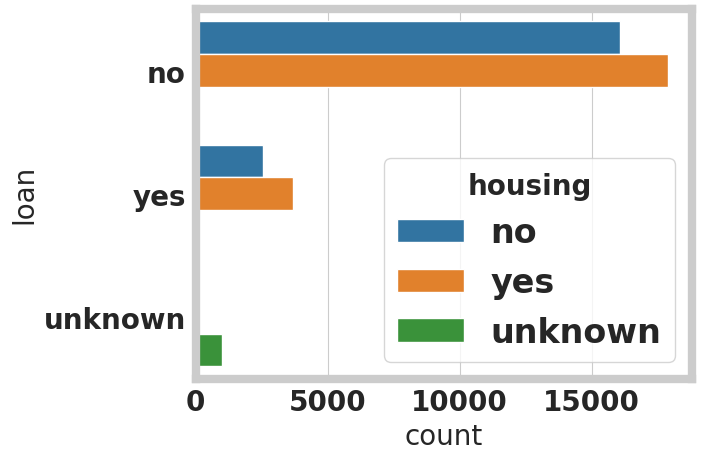

In [31]:
sns.countplot(raw_df, y = 'loan', hue = 'housing')